
# Try to optimized $\beta$ and $\theta$ of th Rio 2014 stationnary model

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

# Data

In [2]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

# all data
DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
dfs = DSS.to_dataframe().reset_index().set_index('row_number')
dfs = dfs[(dfs.sume<1e-4) & (dfs.sumn<1e-4)]
dfs['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)

# Wind data
dfw = pd.read_csv(WD['era5']).set_index('row_number')

# all in one 
ds = pd.concat([dfs, dfw[['iews', 'inss']]], axis=1).dropna().to_xarray()

nofilter__swot2kmnaive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed


In [3]:
ds

<xarray.Dataset> Size: 54MB
Dimensions:        (row_number: 150034)
Coordinates:
  * row_number     (row_number) int64 1MB 143 144 145 ... 404016 404017 404018
Data variables: (12/44)
    id_comb        (row_number) object 1MB 'nofilter__swot2kmnaive_etaf__rio_...
    sume           (row_number) float64 1MB -1.061e-05 -1.105e-05 ... -1.593e-05
    acce           (row_number) float64 1MB -7.905e-06 -8.596e-06 ... -8.778e-06
    exce_acc       (row_number) float64 1MB -2.704e-06 -2.457e-06 ... -7.157e-06
    core           (row_number) float64 1MB 1.226e-05 1.211e-05 ... 1.516e-05
    exce_cor       (row_number) float64 1MB -2.287e-05 -2.317e-05 ... -3.11e-05
    ...             ...
    drifter_type   (row_number) object 1MB 'CARTHE' 'CARTHE' ... 'HEREON'
    depth          (row_number) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    phi            (row_number) float64 1MB 1.818 1.818 1.818 ... -1.802 -1.802
    f              (row_number) float64 1MB 9.818e-05 9.817e-05 ... 9.58e-05
    iews           (row_number) float64 1MB 0.2505 0.2448 ... -0.03086 -0.03245
    inss           (row_number) float64 1MB -0.1629 -0.1542 ... -0.0546 -0.05529

In [4]:
def update_wdterm(beta0, theta0, dsi):
    ds = dsi.copy()
    theta0 = - theta0 * np.pi / 180 * np.sign(ds.f)
    uek_e = beta0 * (np.cos(theta0) * ds.iews - np.sin(theta0) * ds.inss)
    uek_n = beta0 * (np.sin(theta0) * ds.iews + np.cos(theta0) * ds.inss)
    ds['wde'] = ds.f * uek_n
    ds['wdn'] = -ds.f * uek_e

    for direction in ['e', 'n'] : 
        if direction == 'e' : l = {'acc':'acce', 'cor':'core', 'ggd':'ggde', 'wd':'wde'}
        if direction == 'n' : l = {'acc':'accn', 'cor':'corn', 'ggd':'ggdn', 'wd':'wdn'}
            
        # sum 
        ds['sum'+direction] = sum([ds[l[v]] for v in l])
    
        # simple var + sum- one term
        for v in l :
            ds[l[v]] = ds[l[v]]
            ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[l[v]]
            
        #2 by 2 product    
        import itertools  
        couple = list(itertools.combinations(list(l.keys()),2))
        for c in couple : 
            ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
            
    return ds

In [81]:
db = 1
dt = 30
DSB =[]
list_beta0 = np.linspace(0, 1.5, 25)
list_theta0 = np.linspace(10, 40, 25)
#list_beta0 = np.linspace(1, 1.1, 25)
#list_theta0 = np.linspace(32, 35, 25)
for theta0 in list_theta0 : 
    D=[]
    for beta0 in list_beta0 :
        D.append(compute_mean_square(update_wdterm(beta0, theta0, ds))/U2)
    DSB.append(xr.concat(D, dim=pd.Index(list_beta0, name='beta')))
dsm = xr.concat(DSB, dim=pd.Index(list_theta0, name='theta'))

In [82]:
dsm['S'] = dsm.Se +dsm.Sn
dsm['B_wd'] = (dsm.Be_wd +dsm.Bn_wd)
dsm['E_wd'] = (dsm.Ee_wd +dsm.En_wd)

# Residual

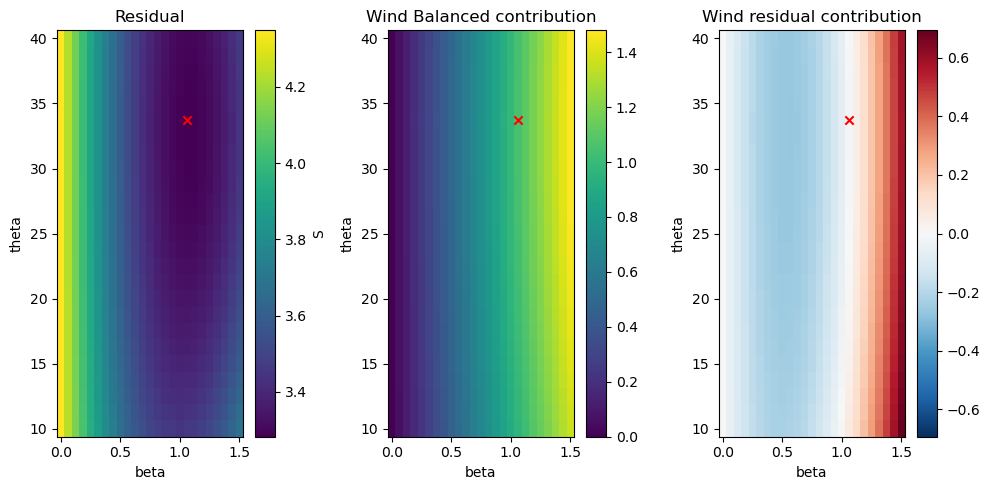

In [83]:
fig, axs = plt.subplots(1, 3, figsize = (10, 5), frameon=False)

ax = axs[0]
dsm.S.plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
betamin = dsm.where(dsm.S == dsm.S.min(), drop=True).beta.values
thetamin = dsm.where(dsm.S == dsm.S.min(), drop=True).theta.values
ax.set_title('Residual')

ax = axs[1]
(dsm.Be_wd +dsm.Bn_wd).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title('Wind Balanced contribution')

ax = axs[2]
(dsm.Ee_wd +dsm.En_wd).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title('Wind residual contribution')

fig.tight_layout()

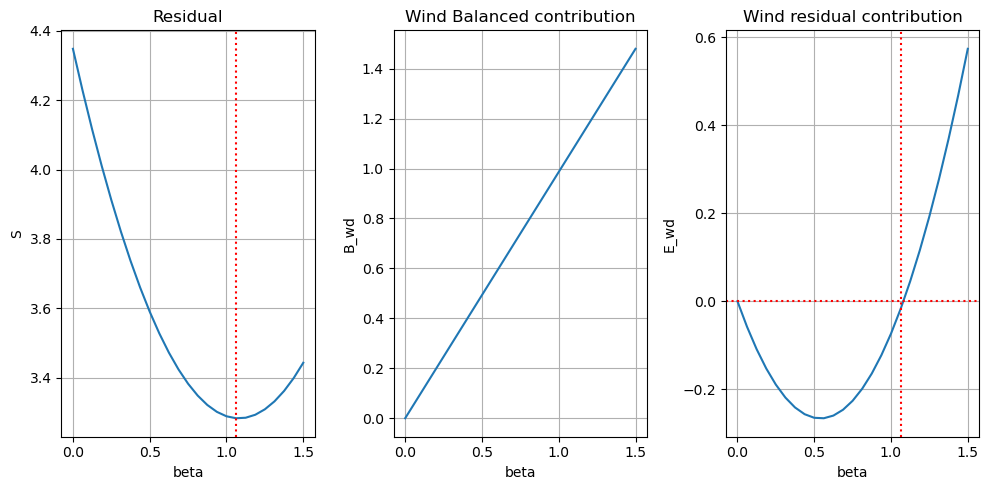

In [84]:
fig, axs = plt.subplots(1, 3, figsize = (10, 5), frameon=False)

ax = axs[0]
dsm.S.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.axvline(betamin, ls=':', c='r')
ax.set_title('Residual')

ax = axs[1]
dsm.B_wd.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.set_title('Wind Balanced contribution')

ax = axs[2]
dsm.E_wd.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.axvline(betamin, ls=':', c='r')
ax.axhline(0, ls=':', c='r')
ax.set_title('Wind residual contribution')

for ax in axs :
    ax.grid()
fig.tight_layout()

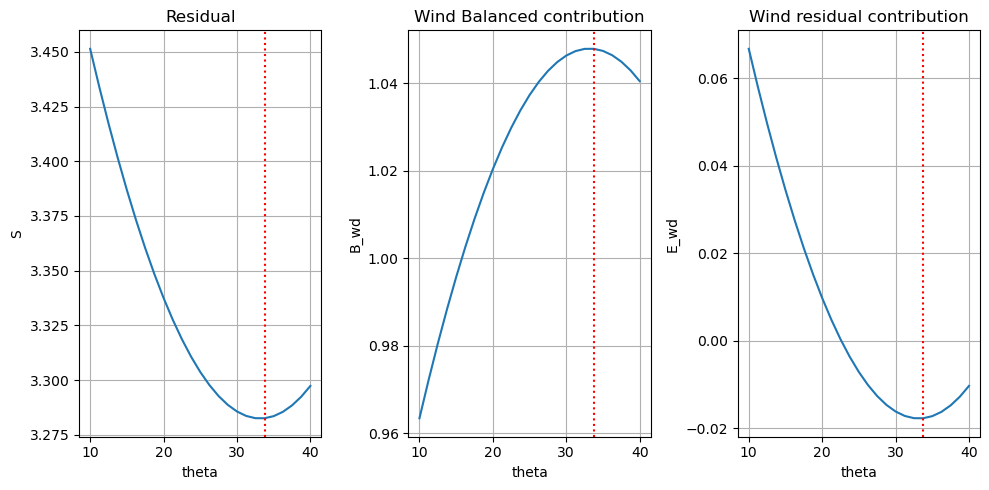

In [85]:
fig, axs = plt.subplots(1, 3, figsize = (10, 5), frameon=False)

ax = axs[0]
dsm.S.sel(beta = betamin, method='nearest').plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_title('Residual')

ax = axs[1]
dsm.B_wd.sel(beta = betamin).plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_title('Wind Balanced contribution')

ax = axs[2]
dsm.E_wd.sel(beta = betamin).plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_title('Wind residual contribution')


for ax in axs :
    ax.grid()
    
fig.tight_layout()

In [80]:
betamin, thetamin

(array([1.07916667]), array([33.125]))

In [ ]:
# with finer grid : beta = 1.07916667, theta = 33.125